# Импорт библиотек + расчет доп. переменных

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.cluster import KMeans
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel('/Users/veronikakozlova/Documents/ВКР HSE /порошки.xlsx')

df["Вес_1_стирки"] = df["Вес/Объем"] / df["Кол-во стирок"]

# Средний вес одной стирки
avg_wash_weight = df["Вес_1_стирки"].mean(skipna=True)

print("Средний вес одной стирки:", avg_wash_weight)

# Заполняем пропуски

df["Кол-во стирок_расчет"] = df["Кол-во стирок"]

mask_missing = df["Кол-во стирок"].isna()

df.loc[mask_missing, "Кол-во стирок_расчет"] = (
    df.loc[mask_missing, "Вес/Объем"] / avg_wash_weight
)

# Цена за 1 стирку

df["Цена_за_1_стирку"] = df["Цена(Безкарты)"] / df["Кол-во стирок_расчет"]

df["Вес_1_стирки"] = df["Вес/Объем"]/df["Кол-во стирок_расчет"]


Средний вес одной стирки: 0.12158154376500367


In [160]:
df= df.dropna()

# Матрица корреляции для числовых признаков

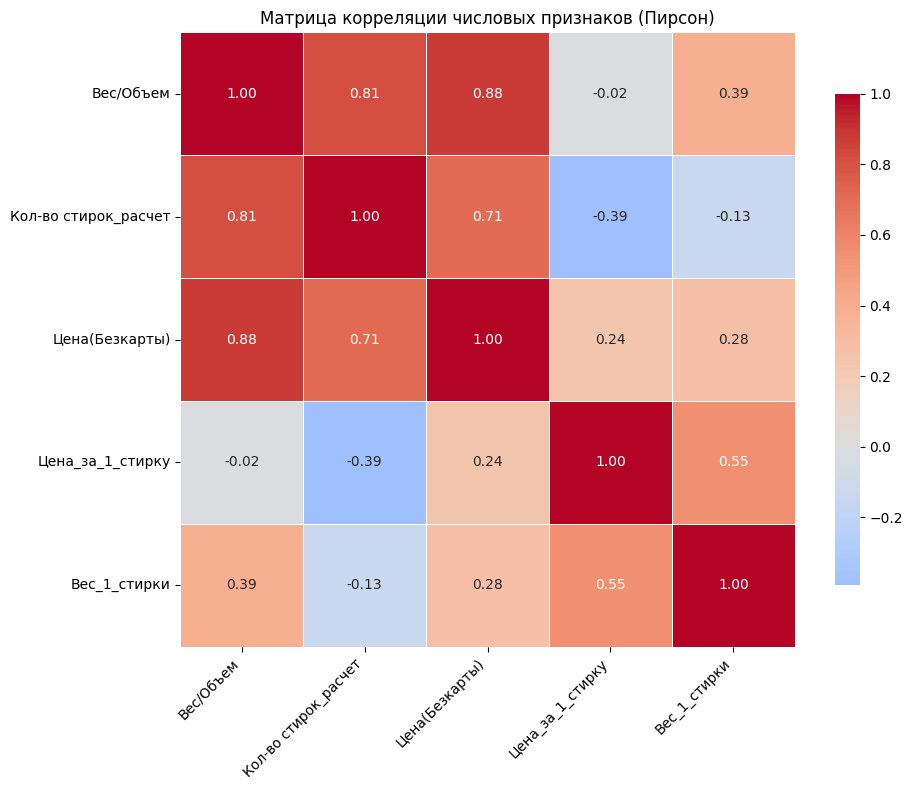

In [ ]:



# Список всех числовых признаков, включая созданные ранее
numeric_all = [
    "Вес/Объем",
    "Кол-во стирок_расчет",
    "Цена(Безкарты)",
    "Цена_за_1_стирку",
    "Вес_1_стирки"
]

# Проверка, что все столбцы существуют в df
existing_numeric = [col for col in numeric_all if col in df.columns]

# Вычисление корреляционной матрицы
corr_matrix = df[existing_numeric].corr(method='pearson')  # можно также spearman

# Построение тепловой карты
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,           
    fmt=".2f",            
    cmap="coolwarm",      
    center=0,             
    square=True,          
    linewidths=0.5,       
    cbar_kws={"shrink": 0.8} 
)
plt.title('Матрица корреляции числовых признаков (Пирсон)')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

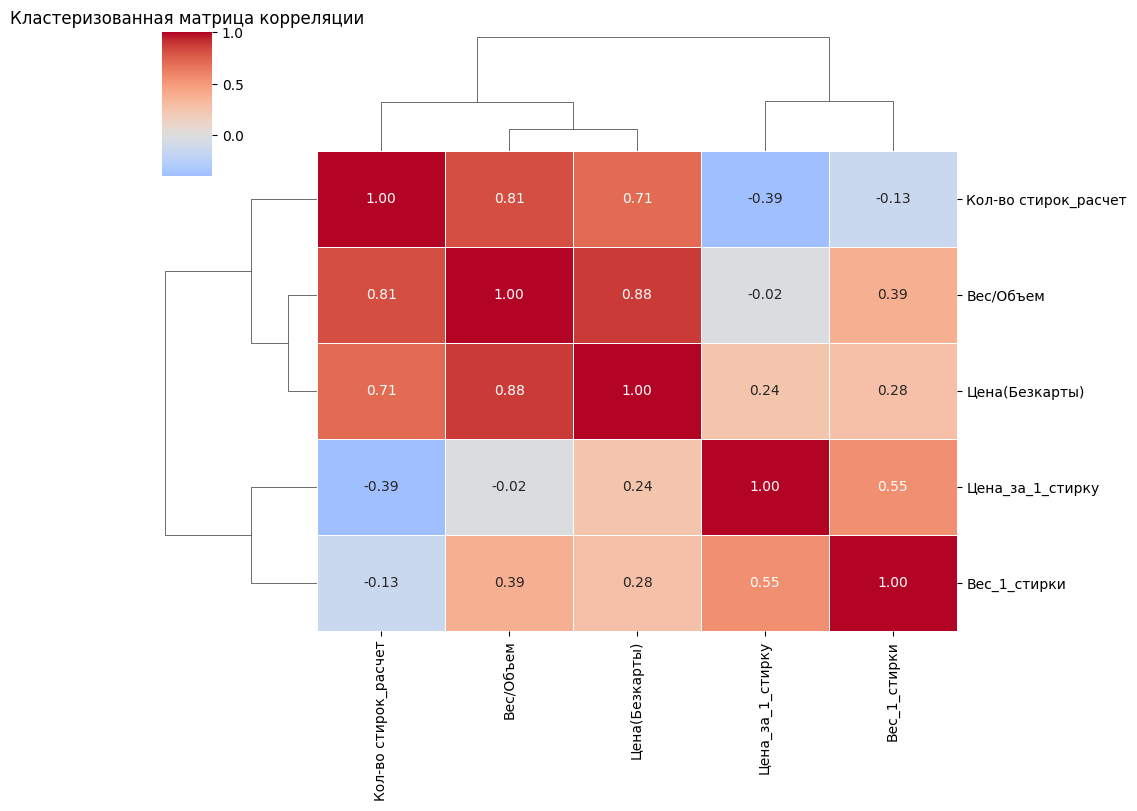

In [162]:
sns.clustermap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    figsize=(10, 8)
)
plt.title('Кластеризованная матрица корреляции')
plt.show()

In [ ]:
# Отбор переменных
numeric_features = [
    "Цена(Безкарты)",
    "Вес_1_стирки",
]

categorical_features = [
    "Аромат/Отдушка",
    "Назначение",
    "Страна"
]

# Препроцессинг

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

# KMeans


pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("cluster", KMeans(n_clusters=3, random_state=42, n_init=10))
])

df["Кластер"] = pipeline.fit_predict(df)

# Анализ кластеров

cluster_summary_numeric = df.groupby("Кластер")[numeric_features].mean()

print("Средние числовые показатели по кластерам:")
print(cluster_summary_numeric)

print("\nРазмеры кластеров:")
print(df["Кластер"].value_counts())



Средние числовые показатели по кластерам:
         Цена(Безкарты)  Вес_1_стирки
Кластер                              
0            849.842667      0.071010
1           2152.888000      0.145318
2            891.267895      0.149013

Размеры кластеров:
Кластер
2    38
0    30
1    20
Name: count, dtype: int64


/var/folders/c_/kz000cy95_d9qk4m43x2b4t80000gn/T/ipykernel_12635/2024174400.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Кластер"] = pipeline.fit_predict(df)


# Метод локтя

In [ ]:


import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.pipeline import Pipeline

# Диапазон количества кластеров
k_range = range(1, 11)

inertias = []

for k in k_range:
    
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),  # тот же ColumnTransformer
        ("cluster", KMeans(n_clusters=k, random_state=42, n_init=10))
    ])
    
    pipeline.fit(df)
    
    inertias.append(pipeline.named_steps["cluster"].inertia_)

# Построение графика
plt.figure(figsize=(8, 6))
plt.plot(k_range, inertias, marker='o')
plt.xlabel("Количество кластеров (k)")
plt.ylabel("Inertia (WSS)")
plt.title("Метод локтя для выбора числа кластеров")
plt.xticks(k_range)
plt.show()

# Проверка качества

In [ ]:


from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

X_transformed = preprocessor.fit_transform(df)

# Обучаем модель (например, k=4 — как в основном анализе)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_transformed)

# Преобразуем в плотный массив
X_dense = X_transformed.toarray()

sil_score = silhouette_score(X_dense, labels)
db_index = davies_bouldin_score(X_dense, labels)
ch_index = calinski_harabasz_score(X_dense, labels)
inertia = kmeans.inertia_

print("Silhouette Score:", sil_score)
print("Davies-Bouldin Index:", db_index)
print("Calinski-Harabasz Index:", ch_index)
print("Inertia:", inertia)

Silhouette Score: 0.261849290631016
Davies-Bouldin Index: 1.3413769625236263
Calinski-Harabasz Index: 34.72717162933398
Inertia: 163.05863017516833


# Визуализация кластеров

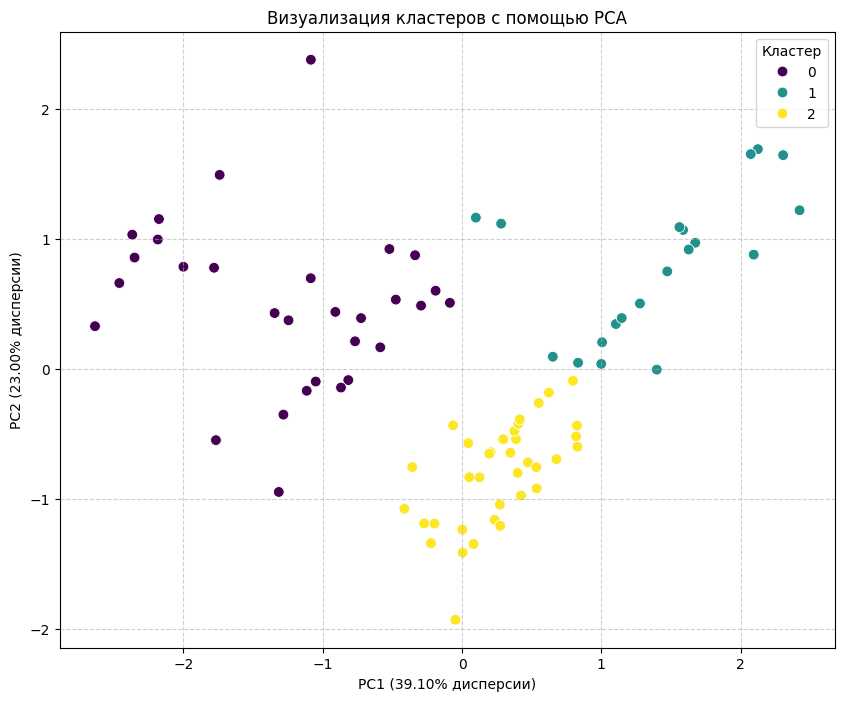

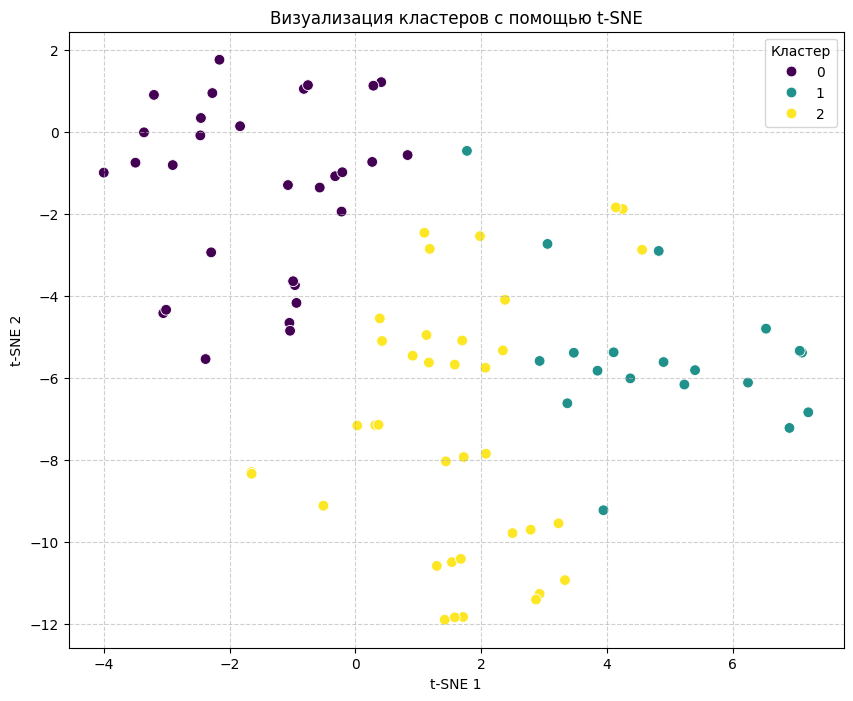

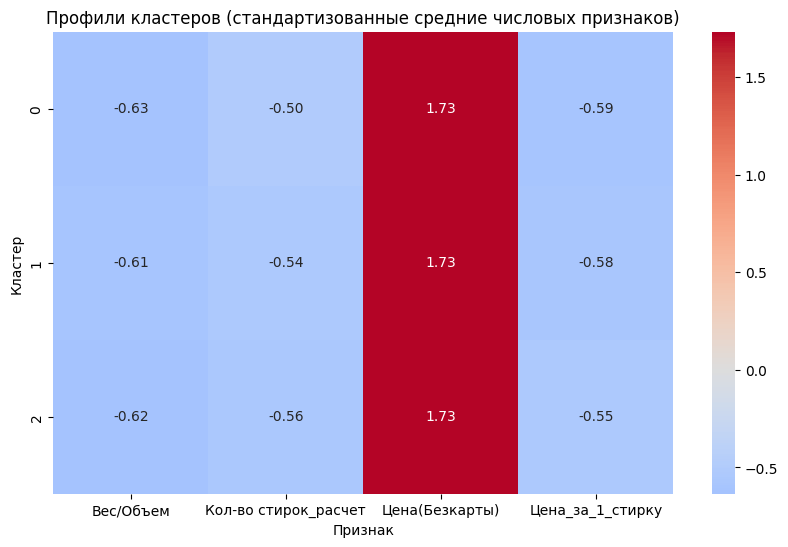

/var/folders/c_/kz000cy95_d9qk4m43x2b4t80000gn/T/ipykernel_12635/1871584599.py:87: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Кластер', y=feat, ax=axes[i], palette='viridis', errorbar=None)
/var/folders/c_/kz000cy95_d9qk4m43x2b4t80000gn/T/ipykernel_12635/1871584599.py:87: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Кластер', y=feat, ax=axes[i], palette='viridis', errorbar=None)
/var/folders/c_/kz000cy95_d9qk4m43x2b4t80000gn/T/ipykernel_12635/1871584599.py:87: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df,

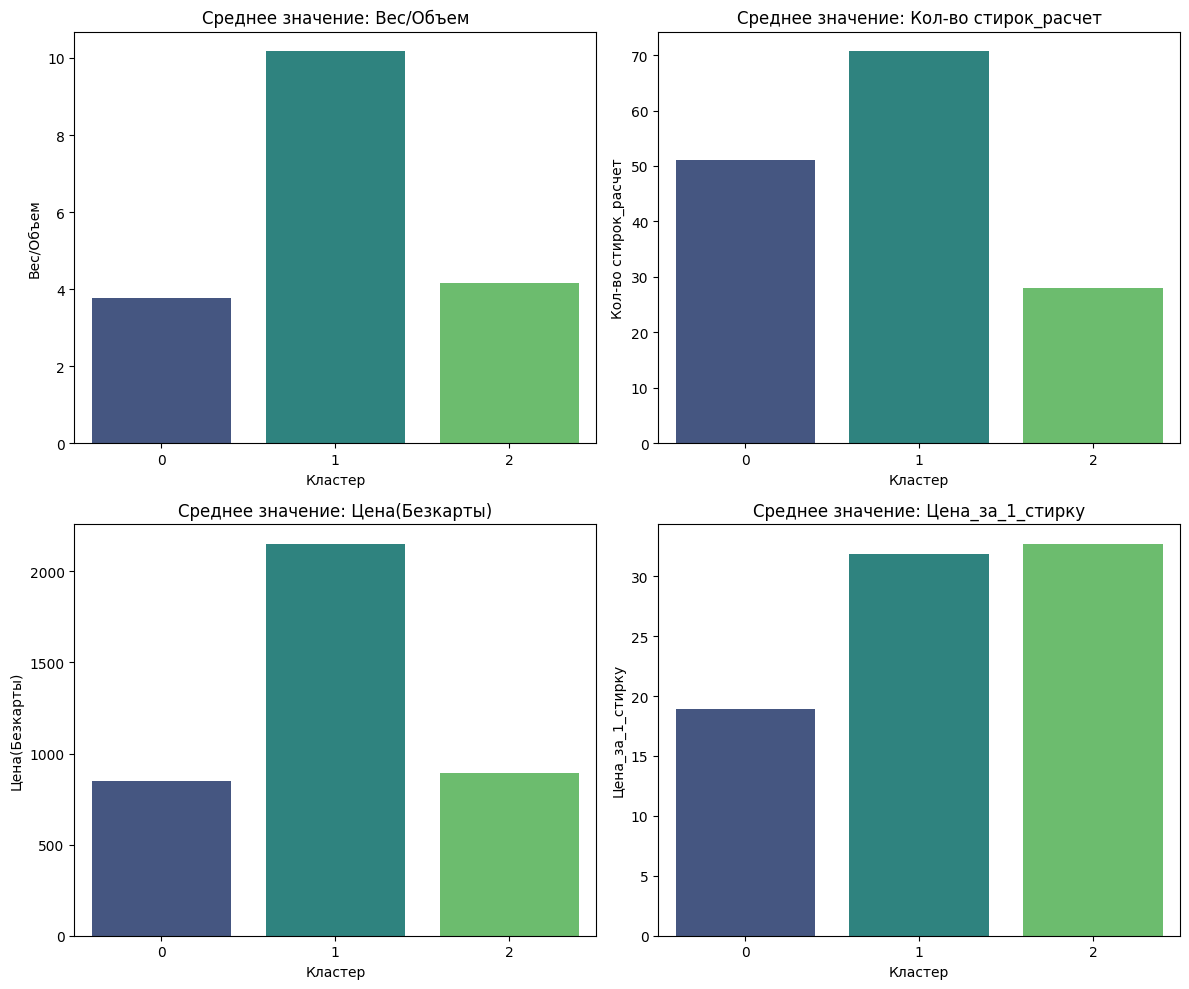

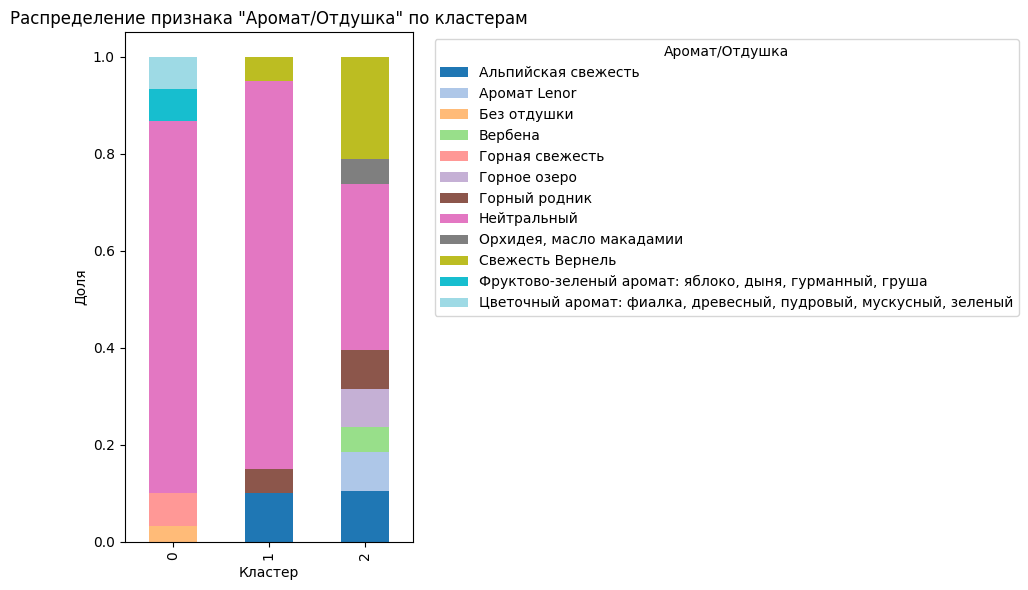

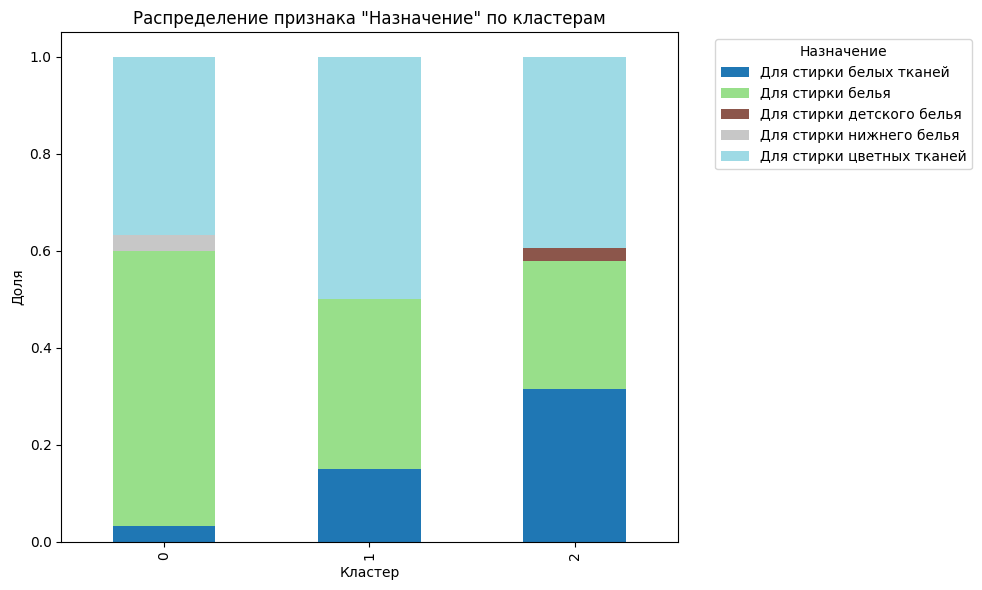

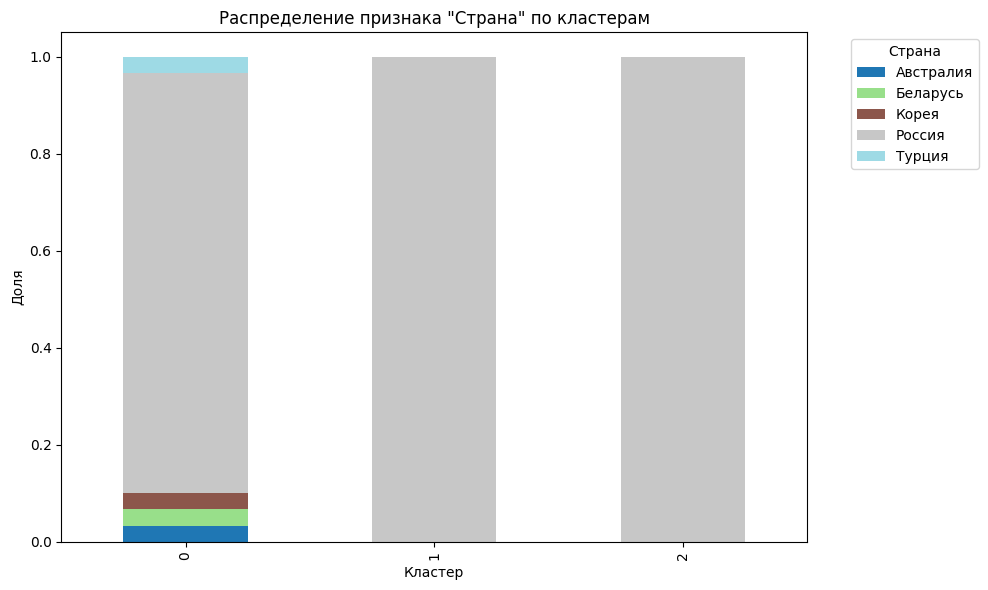

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE  
import pandas as pd
import numpy as np

X_transformed = preprocessor.fit_transform(df)

#  PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_transformed.toarray())  # преобразуем в плотный массив

#  DataFrame для удобства
pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['Кластер'] = df['Кластер'].values

# Построение scatter plot
plt.figure(figsize=(10, 8))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='Кластер', palette='viridis', s=60)
plt.title('Визуализация кластеров с помощью PCA')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} дисперсии)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} дисперсии)')
plt.legend(title='Кластер')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Визуализация с t-SNE для более чёткого разделения

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_transformed.toarray())

tsne_df = pd.DataFrame(X_tsne, columns=['TSNE1', 'TSNE2'])
tsne_df['Кластер'] = df['Кластер'].values

plt.figure(figsize=(10, 8))
sns.scatterplot(data=tsne_df, x='TSNE1', y='TSNE2', hue='Кластер', palette='viridis', s=60)
plt.title('Визуализация кластеров с помощью t-SNE')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.legend(title='Кластер')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Профили кластеров по числовым признакам

# Нормализация средних значений для лучшей сравнимости
numeric_features = [
    "Вес/Объем",
    "Кол-во стирок_расчет",
    "Цена(Безкарты)",
    "Цена_за_1_стирку"
]

# Вычисляение средних по кластерам
cluster_means = df.groupby('Кластер')[numeric_features].mean()

# Для наглядности можно стандартизировать средние (Z-score) или MinMax
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
cluster_means_scaled = pd.DataFrame(
    scaler.fit_transform(cluster_means.T).T,  # транспонируем, чтобы масштабировать по строкам?
    columns=numeric_features,
    index=cluster_means.index
)

# Тепловая карта
plt.figure(figsize=(10, 6))
sns.heatmap(cluster_means_scaled, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Профили кластеров (стандартизованные средние числовых признаков)')
plt.xlabel('Признак')
plt.ylabel('Кластер')
plt.show()

# Столбчатая диаграмма 
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()
for i, feat in enumerate(numeric_features):
    sns.barplot(data=df, x='Кластер', y=feat, ax=axes[i], palette='viridis', errorbar=None)
    axes[i].set_title(f'Среднее значение: {feat}')
    axes[i].set_xlabel('Кластер')
plt.tight_layout()
plt.show()

# Профили кластеров по категориальным признакам

categorical_features = [
    "Аромат/Отдушка",
    "Назначение",
    "Страна"
]

for cat in categorical_features:
    # Таблица сопряжённости: кластеры vs категории
    crosstab = pd.crosstab(df['Кластер'], df[cat], normalize='index')  # нормализация по строкам (внутри кластера)
    
    # Визуализация в виде stacked bar chart
    crosstab.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='tab20')
    plt.title(f'Распределение признака "{cat}" по кластерам')
    plt.xlabel('Кластер')
    plt.ylabel('Доля')
    plt.legend(title=cat, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

In [171]:
df.to_excel('/Users/veronikakozlova/Documents/ВКР HSE /кластеры-порошки.xlsx')